In [1]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options #use to set chrome settings
from selenium.webdriver.common.by import By #to find elements
import numpy as np #for numerical operation
import pandas as pd #for data processing
import matplotlib.pyplot as plt #for visualization
import seaborn as sns #for visualization
import plotly.express as px #for visualization, learned from geeksforgeeks website
import plotly.io as pio
pio.renderers.default = "notebook_connected"

In [2]:
options = Options()
options.add_argument("--headless") #running the chrome
options.add_argument("--no-sandbox") #for permission errors
driver = webdriver.Chrome(options=options)

In [3]:
url = "https://www.basketball-reference.com/leagues/NBA_2025_per_game.html"
driver.get(url) #opens the webpage

In [4]:
table = driver.find_element(By.ID, "per_game_stats") #locating table using the ID
table_html = table.get_attribute('outerHTML') #getting complete HTML of the table

In [5]:
df = pd.read_html(table_html)[0] #viewing tables using pandas

In [6]:
df = df[df['Player'] != 'Player'] #dropping the repeated header

In [7]:
df.reset_index(drop=True, inplace=True) #reseting index and viewing the first 30 rows
df.head(5)

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
0,1,Shai Gilgeous-Alexander,26,OKC,PG,76,76,34.2,11.3,21.8,...,0.9,4.1,5.0,6.4,1.7,1.0,2.4,2.2,32.7,"MVP-1,DPOY-10,CPOY-8,AS,NBA1"
1,2,Giannis Antetokounmpo,30,MIL,PF,67,67,34.2,11.8,19.7,...,2.2,9.7,11.9,6.5,0.9,1.2,3.1,2.3,30.4,"MVP-3,DPOY-8,AS,NBA1"
2,3,Nikola Jokić,29,DEN,C,70,70,36.7,11.2,19.5,...,2.9,9.9,12.7,10.2,1.8,0.6,3.3,2.3,29.6,"MVP-2,CPOY-2,AS,NBA1"
3,4,Luka Dončić,25,2TM,PG,50,50,35.4,9.2,20.5,...,0.8,7.4,8.2,7.7,1.8,0.4,3.6,2.5,28.2,NaN
4,4,Luka Dončić,25,DAL,PG,22,22,35.7,9.8,21.2,...,0.7,7.6,8.3,7.8,2.0,0.4,3.4,2.6,28.1,NaN


In [8]:
df.to_csv('nba_game.csv', index=False) #saving the data into csv file

In [9]:
#reading the csv file and converting it into a pandas dataframe that is stored in variable data
data = pd.read_csv("nba_game.csv")

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Rk      735 non-null    float64
 1   Player  736 non-null    object 
 2   Age     735 non-null    float64
 3   Team    735 non-null    object 
 4   Pos     735 non-null    object 
 5   G       735 non-null    float64
 6   GS      735 non-null    float64
 7   MP      735 non-null    float64
 8   FG      735 non-null    float64
 9   FGA     735 non-null    float64
 10  FG%     732 non-null    float64
 11  3P      735 non-null    float64
 12  3PA     735 non-null    float64
 13  3P%     691 non-null    float64
 14  2P      735 non-null    float64
 15  2PA     735 non-null    float64
 16  2P%     725 non-null    float64
 17  eFG%    732 non-null    float64
 18  FT      735 non-null    float64
 19  FTA     735 non-null    float64
 20  FT%     694 non-null    float64
 21  ORB     735 non-null    float64
 22  DR

In [11]:
data.head(5)

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
0,1.0,Shai Gilgeous-Alexander,26.0,OKC,PG,76.0,76.0,34.2,11.3,21.8,...,0.9,4.1,5.0,6.4,1.7,1.0,2.4,2.2,32.7,"MVP-1,DPOY-10,CPOY-8,AS,NBA1"
1,2.0,Giannis Antetokounmpo,30.0,MIL,PF,67.0,67.0,34.2,11.8,19.7,...,2.2,9.7,11.9,6.5,0.9,1.2,3.1,2.3,30.4,"MVP-3,DPOY-8,AS,NBA1"
2,3.0,Nikola Jokić,29.0,DEN,C,70.0,70.0,36.7,11.2,19.5,...,2.9,9.9,12.7,10.2,1.8,0.6,3.3,2.3,29.6,"MVP-2,CPOY-2,AS,NBA1"
3,4.0,Luka Dončić,25.0,2TM,PG,50.0,50.0,35.4,9.2,20.5,...,0.8,7.4,8.2,7.7,1.8,0.4,3.6,2.5,28.2,NaN
4,4.0,Luka Dončić,25.0,DAL,PG,22.0,22.0,35.7,9.8,21.2,...,0.7,7.6,8.3,7.8,2.0,0.4,3.4,2.6,28.1,NaN


In [12]:
data[["PTS","FG","eFG%", "3P", "2P", "FT", "ORB", "DRB", "STL", "AST", "BLK", "TOV", "PF"]].describe()

,PTS,FG,eFG%,3P,2P,FT,ORB,DRB,STL,AST,BLK,TOV,PF
count,735.000000,735.000000,732.000000,735.000000,735.000000,735.000000,735.000000,735.000000,735.000000,735.000000,735.000000,735.000000,735.000000
mean,8.564354,3.139456,0.522527,1.000816,2.139184,1.290748,0.914966,2.601497,0.651293,2.060136,0.387211,1.068844,1.525170
std,6.443135,2.307220,0.126351,0.897817,1.806381,1.330903,0.752865,1.767612,0.423551,1.801264,0.388352,0.815113,0.765596
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.750000,1.400000,0.482000,0.300000,0.800000,0.400000,0.400000,1.300000,0.300000,0.800000,0.100000,0.500000,0.900000
50%,7.100000,2.600000,0.531500,0.800000,1.600000,0.800000,0.700000,2.300000,0.600000,1.500000,0.300000,0.900000,1.600000
75%,11.400000,4.200000,0.576000,1.600000,2.900000,1.600000,1.200000,3.400000,0.900000,2.700000,0.500000,1.450000,2.100000
max,32.700000,11.800000,1.500000,5.000000,11.600000,7.900000,4.600000,10.100000,3.000000,11.600000,3.800000,4.700000,3.500000


### Insights:
Regarding scoring overview, mean us greater than median, which means the data is right skewed in this case. Few players are very high scroing which is 32.7. Also with 6.4 std in PTS, it suggests that players have different roles and contribute in different ways. Effective FG% around 52% tells moderate overall scoring efficiency. The maximum in eFG% is 150%, which might be liely a data or calculation issue. Interms of shot selection, it looks like players make roughly twice as many 2-point shots as 3-points shots. Defensive rebounds occur more frequently than offensive rebounds. 

In [13]:
data = data.drop(data.columns[30], axis=1) #dropping the column award as there is not anything we need
data.head(10)

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,1.0,Shai Gilgeous-Alexander,26.0,OKC,PG,76.0,76.0,34.2,11.3,21.8,...,0.898,0.9,4.1,5.0,6.4,1.7,1.0,2.4,2.2,32.7
1,2.0,Giannis Antetokounmpo,30.0,MIL,PF,67.0,67.0,34.2,11.8,19.7,...,0.617,2.2,9.7,11.9,6.5,0.9,1.2,3.1,2.3,30.4
2,3.0,Nikola Jokić,29.0,DEN,C,70.0,70.0,36.7,11.2,19.5,...,0.800,2.9,9.9,12.7,10.2,1.8,0.6,3.3,2.3,29.6
3,4.0,Luka Dončić,25.0,2TM,PG,50.0,50.0,35.4,9.2,20.5,...,0.782,0.8,7.4,8.2,7.7,1.8,0.4,3.6,2.5,28.2
4,4.0,Luka Dončić,25.0,DAL,PG,22.0,22.0,35.7,9.8,21.2,...,0.767,0.7,7.6,8.3,7.8,2.0,0.4,3.4,2.6,28.1
5,4.0,Luka Dončić,25.0,LAL,PG,28.0,28.0,35.1,8.8,20.0,...,0.791,0.9,7.2,8.1,7.5,1.6,0.4,3.7,2.4,28.2
6,5.0,Anthony Edwards,23.0,MIN,SG,79.0,79.0,36.3,9.1,20.4,...,0.837,0.8,4.9,5.7,4.5,1.2,0.6,3.2,1.9,27.6
7,6.0,Jayson Tatum,26.0,BOS,PF,72.0,72.0,36.4,9.2,20.3,...,0.814,0.7,8.0,8.7,6.0,1.1,0.5,2.9,2.2,26.8
8,7.0,Kevin Durant,36.0,PHO,PF,62.0,62.0,36.5,9.5,18.1,...,0.839,0.4,5.7,6.0,4.2,0.8,1.2,3.1,1.7,26.6
9,8.0,Tyrese Maxey,24.0,PHI,PG,52.0,52.0,37.7,9.2,21.0,...,0.879,0.3,3.1,3.3,6.1,1.8,0.4,2.4,2.2,26.3


In [14]:
duplicate_rows_data = df[data.duplicated()] #checking if there are any duplicate entries
print("number of duplicate rows: ", duplicate_rows_data.shape)

number of duplicate rows:  (0, 31)


In [15]:
#Let's check the number of distinct values in each column
for column in data.columns:
    num_distinct_values = len(df[column].unique())
    print(f"{column}: {num_distinct_values} distinct values")

Rk: 570 distinct values
Player: 570 distinct values
Age: 23 distinct values
Team: 33 distinct values
Pos: 6 distinct values
G: 83 distinct values
GS: 83 distinct values
MP: 312 distinct values
FG: 99 distinct values
FGA: 181 distinct values
FG%: 274 distinct values
3P: 43 distinct values
3PA: 97 distinct values
3P%: 219 distinct values
2P: 82 distinct values
2PA: 128 distinct values
2P%: 272 distinct values
eFG%: 273 distinct values
FT: 64 distinct values
FTA: 78 distinct values
FT%: 271 distinct values
ORB: 42 distinct values
DRB: 86 distinct values
TRB: 107 distinct values
AST: 83 distinct values
STL: 24 distinct values
BLK: 26 distinct values
TOV: 42 distinct values
PF: 36 distinct values
PTS: 222 distinct values


No duplicate rows which is good, however, the dataset contains 735 entries but the players shows only 570 unique players meaning some players appear multiple times in the data. Performance metrics like FG%, 3P%, 2P%, .etc have high variability, which makes them sutiable for regression analysis.

In [16]:
# Checking null values
print(data.isnull().sum())

Rk         1
Player     0
Age        1
Team       1
Pos        1
G          1
GS         1
MP         1
FG         1
FGA        1
FG%        4
3P         1
3PA        1
3P%       45
2P         1
2PA        1
2P%       11
eFG%       4
FT         1
FTA        1
FT%       42
ORB        1
DRB        1
TRB        1
AST        1
STL        1
BLK        1
TOV        1
PF         1
PTS        1
dtype: int64


In [17]:
duplicate_players = df[df["Player"].duplicated(keep=False)]
duplicate_players.sort_values("Player")

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
331,271,AJ Johnson,20,2TM,SG,29,11,22.0,2.8,7.3,...,0.3,1.8,2.0,2.6,0.4,0.1,1.2,1.7,7.6,NaN
333,271,AJ Johnson,20,WAS,SG,22,11,27.0,3.4,8.8,...,0.4,2.0,2.4,3.1,0.5,0.1,1.4,2.3,9.1,NaN
332,271,AJ Johnson,20,MIL,SG,7,0,6.3,1.1,2.7,...,0.0,1.0,1.0,1.0,0.1,0.0,0.6,0.0,2.9,NaN
678,521,Alex Len,31,2TM,C,46,7,8.3,0.7,1.4,...,0.8,1.2,2.1,0.8,0.2,0.5,0.4,1.2,1.6,NaN
679,521,Alex Len,31,SAC,C,36,3,7.2,0.6,1.1,...,0.7,1.1,1.8,0.8,0.2,0.5,0.3,1.0,1.4,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,326,Zach Collins,27,2TM,PF,64,12,15.3,2.4,4.7,...,1.6,2.9,4.5,1.7,0.5,0.5,0.9,2.1,6.4,NaN
408,326,Zach Collins,27,CHI,PF,28,8,19.7,3.3,6.1,...,2.3,4.4,6.7,2.1,0.5,0.5,1.3,2.2,8.6,NaN
36,29,Zach LaVine,29,SAC,SG,32,32,36.6,8.2,16.0,...,0.3,3.2,3.5,3.8,0.6,0.1,2.7,1.8,22.4,NaN
35,29,Zach LaVine,29,CHI,SF,42,42,34.1,8.6,16.9,...,0.3,4.5,4.8,4.5,0.9,0.2,2.9,1.5,24.0,NaN


In [18]:
#Some players appears twice, so lets only keep 2TM rows for players who appears multiple times.
player_counts = df["Player"].value_counts()

In [19]:
single_players = player_counts[player_counts == 1].index

In [20]:
multi_players = player_counts[player_counts > 1].index

In [21]:
df_clean = df[
    (df["Player"].isin(single_players)) |
    ((df["Player"].isin(multi_players)) & (df["Team"] == "2TM"))
]

In [22]:
df_clean["Player"].nunique()
df_clean.shape

(566, 31)

In [23]:
df_clean.head(10)

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
0,1,Shai Gilgeous-Alexander,26,OKC,PG,76,76,34.2,11.3,21.8,...,0.9,4.1,5.0,6.4,1.7,1.0,2.4,2.2,32.7,"MVP-1,DPOY-10,CPOY-8,AS,NBA1"
1,2,Giannis Antetokounmpo,30,MIL,PF,67,67,34.2,11.8,19.7,...,2.2,9.7,11.9,6.5,0.9,1.2,3.1,2.3,30.4,"MVP-3,DPOY-8,AS,NBA1"
2,3,Nikola Jokić,29,DEN,C,70,70,36.7,11.2,19.5,...,2.9,9.9,12.7,10.2,1.8,0.6,3.3,2.3,29.6,"MVP-2,CPOY-2,AS,NBA1"
3,4,Luka Dončić,25,2TM,PG,50,50,35.4,9.2,20.5,...,0.8,7.4,8.2,7.7,1.8,0.4,3.6,2.5,28.2,NaN
6,5,Anthony Edwards,23,MIN,SG,79,79,36.3,9.1,20.4,...,0.8,4.9,5.7,4.5,1.2,0.6,3.2,1.9,27.6,"MVP-7,CPOY-3,AS,NBA2"
7,6,Jayson Tatum,26,BOS,PF,72,72,36.4,9.2,20.3,...,0.7,8.0,8.7,6.0,1.1,0.5,2.9,2.2,26.8,"MVP-4,CPOY-10,AS,NBA1"
8,7,Kevin Durant,36,PHO,PF,62,62,36.5,9.5,18.1,...,0.4,5.7,6.0,4.2,0.8,1.2,3.1,1.7,26.6,AS
9,8,Tyrese Maxey,24,PHI,PG,52,52,37.7,9.2,21.0,...,0.3,3.1,3.3,6.1,1.8,0.4,2.4,2.2,26.3,CPOY-10
10,9,Cade Cunningham,23,DET,PG,70,70,35.0,9.8,20.8,...,0.8,5.3,6.1,9.1,1.0,0.8,4.4,2.8,26.1,"MVP-7,AS,NBA3"
11,10,Jalen Brunson,28,NYK,PG,65,65,35.4,9.0,18.5,...,0.4,2.5,2.9,7.3,0.9,0.1,2.5,2.1,26.0,"MVP-10,CPOY-1,AS,NBA2"


In [24]:
df_clean = df_clean.copy()

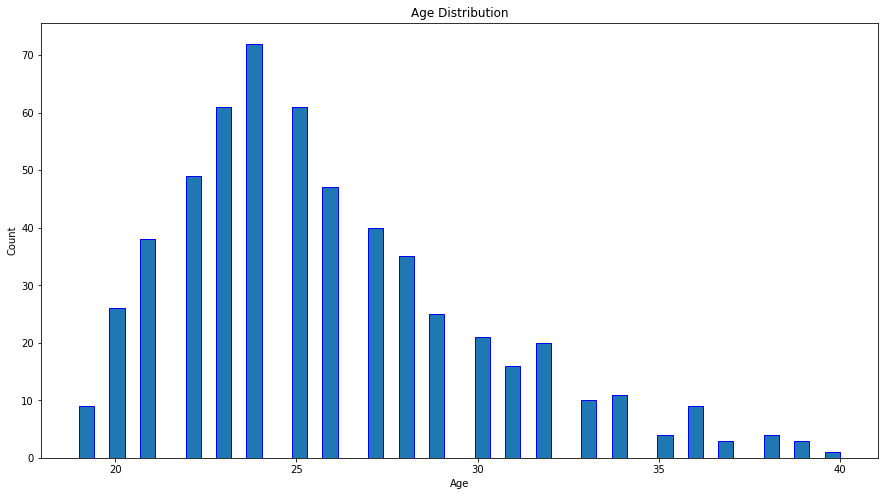

In [25]:
#plotting histogram on age
df_clean["Age"] = pd.to_numeric(df_clean["Age"], errors="coerce")
age = df_clean["Age"].dropna()

plt.figure(figsize=(15,8))
plt.hist(age, bins=50, edgecolor= 'blue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

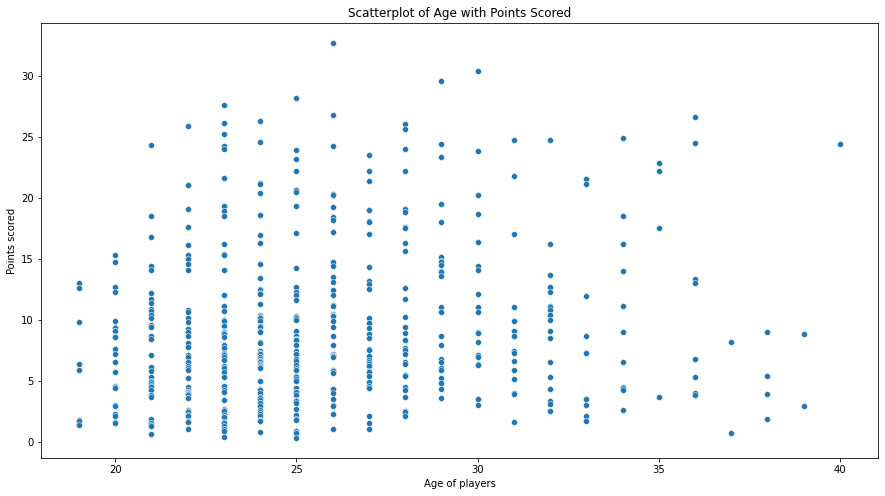

In [51]:
#plotting scatter graph using seaborn to know about relation between points scored and age
plt.figure(figsize=(15,8))
sns.scatterplot(data=df_clean, x='Age', y='PTS')
plt.title('Scatterplot of Age with Points Scored')
plt.xlabel('Age of players')
plt.ylabel('Points scored')
plt.show()

In [27]:
df_clean[['Age','PTS']].corr()

,Age
Age,1.0


In [28]:
df_clean.dtypes

Rk         object
Player     object
Age       float64
Team       object
Pos        object
G          object
GS         object
MP         object
FG         object
FGA        object
FG%        object
3P         object
3PA        object
3P%        object
2P         object
2PA        object
2P%        object
eFG%       object
FT         object
FTA        object
FT%        object
ORB        object
DRB        object
TRB        object
AST        object
STL        object
BLK        object
TOV        object
PF         object
PTS        object
Awards     object
dtype: object

In [29]:
#Changing the data type from object to float
df_clean = df_clean.copy()

numeric_cols = [
    'Age','G','GS','MP','FG','FGA','FG%','3P','3PA','3P%',
    '2P','2PA','2P%','eFG%','FT','FTA','FT%','ORB','DRB',
    'TRB','AST','STL','BLK','TOV','PF','PTS'
]

df_clean[numeric_cols] = df_clean[numeric_cols].apply(pd.to_numeric, errors='coerce')
df_clean = df_clean.dropna(subset=numeric_cols)

## Insights:

The age distribution graph shows that most of the playes are of age between 22 and 28 years, highest in between 23 and 24 years. The number of players after 30 are declining. Therefore, the peak performance is between 23 and 27 years.

Scatterplot of age with points scored suggests that players of age between 23 and 30 scores the most, however, there is no strong trend. Also, the correlation between age and points scored is 0.13 which means they have very weak positive relation which means age does not pla that much role interms of scoring.

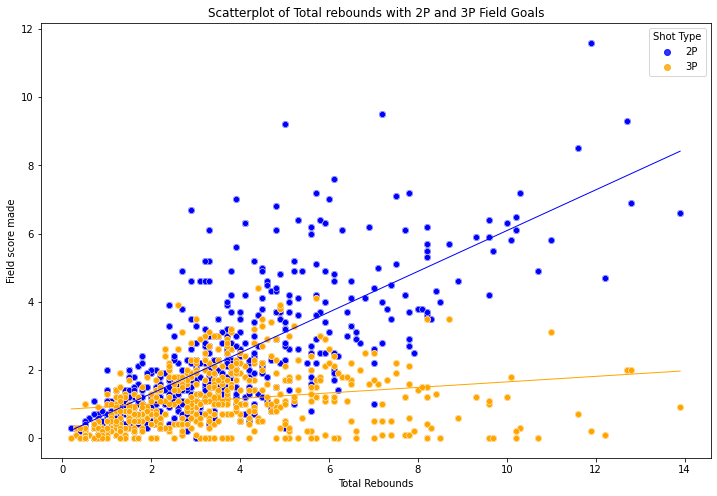

Correlation cofficient between total rebounds and 2-point field goals (r): 0.7549071308322901
Correlation cofficient between total rebounds and 3-point field goals (r): 0.2125616564786006


In [30]:
plt.figure(figsize=(12,8))

sns.regplot(data=df_clean, x='TRB', y='2P', ci=None, line_kws={'linewidth': 1}, label='2P', color='blue')
sns.scatterplot(data=df_clean, x='TRB', y='2P', color='blue')

sns.regplot(data=df_clean, x='TRB', y='3P', ci=None, line_kws={'linewidth': 1}, label='3P', color='orange')
sns.scatterplot(data=df_clean, x='TRB', y='3P', color='orange')

plt.title('Scatterplot of Total rebounds with 2P and 3P Field Goals')
plt.xlabel('Total Rebounds')
plt.ylabel('Field score made')
plt.legend(title='Shot Type')
plt.show()
r = df_clean['TRB'].corr(df_clean['2P'])
print(f"Correlation cofficient between total rebounds and 2-point field goals (r): {r}")
r = df_clean['TRB'].corr(df_clean['3P'])
print(f"Correlation cofficient between total rebounds and 3-point field goals (r): {r}")

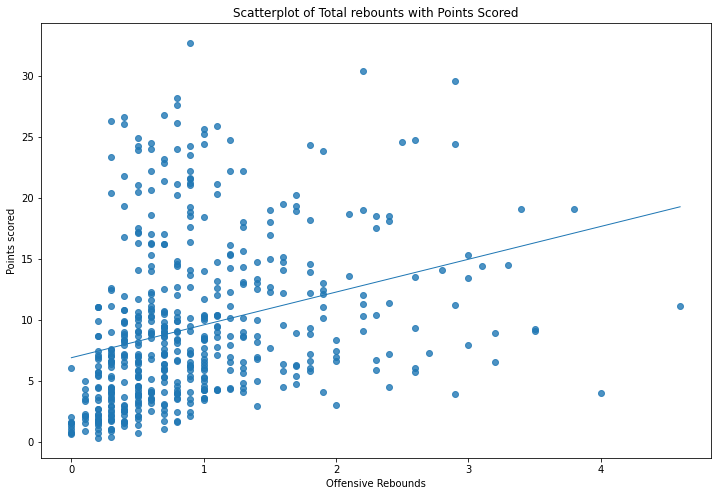

Correlation cofficient (r): 0.2970772654900201


In [31]:
#plotting the regression line
plt.figure(figsize=(12,8))
sns.regplot(data=df_clean, x='ORB', y='PTS', ci=None, line_kws={'linewidth': 1})
plt.title('Scatterplot of Total rebounts with Points Scored')
plt.xlabel('Offensive Rebounds')
plt.ylabel('Points scored')
plt.show()
r = df_clean['ORB'].corr(df_clean['PTS'])
print(f"Correlation cofficient (r): {r}")

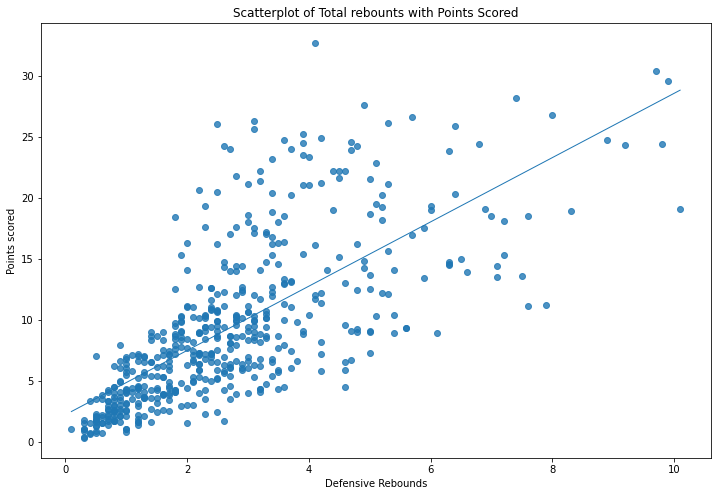

Correlation cofficient (r): 0.7121272789496902


In [32]:
#plotting the regression line
plt.figure(figsize=(12,8))
sns.regplot(data=df_clean, x='DRB', y='PTS', ci=None, line_kws={'linewidth': 1})
plt.title('Scatterplot of Total rebounts with Points Scored')
plt.xlabel('Defensive Rebounds')
plt.ylabel('Points scored')
plt.show()
r = df_clean['DRB'].corr(df_clean['PTS'])
print(f"Correlation cofficient (r): {r}")

## Insights:

Form the picture we see that, there is strong positive correlation between defensive rebounds with total points scored (r=0.71), whereas offensive rebounds show a weaker relationship (r=0.30). Also, total rebounds are strongly correlated with 2-point field goals (0.75) but only weakly correlated with 3-point filed goals (r=0.21). It indicates that player score and rebound more because of the type of role they play like power forwards and centers.

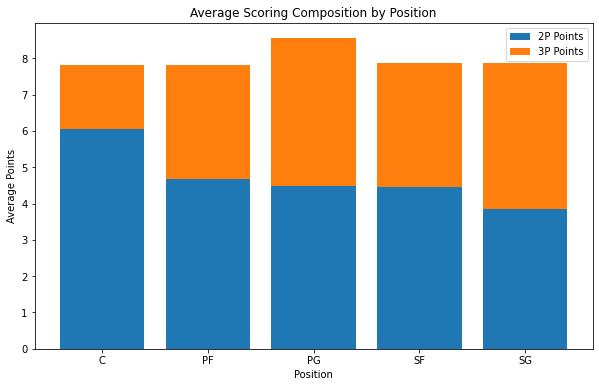

In [33]:
# Creating scoring components
df_clean["Points_2P"] = 2 * df_clean["2P"]
df_clean["Points_3P"] = 3 * df_clean["3P"]

avg_scoring = df_clean.groupby("Pos")[["Points_2P", "Points_3P"]].mean()


plt.figure(figsize=(10,6))
plt.bar(avg_scoring.index, avg_scoring["Points_2P"], label="2P Points")
plt.bar(
    avg_scoring.index,
    avg_scoring["Points_3P"],
    bottom=avg_scoring["Points_2P"],
    label="3P Points"
)

plt.title("Average Scoring Composition by Position")
plt.xlabel("Position")
plt.ylabel("Average Points")
plt.legend()

plt.show()

### Insights:

Scoring is different based on positions. Players playing as center have more average 2 point field goals, reflecting their interior role. Whereas, shooting guards and point guards show higher proportion of scoring from 3-points shots. 

In [34]:
#Plotting the scatter plot using plotty.express
fig = px.scatter(data_frame=df_clean, x='MP', y='PTS', trendline='ols', title='Relationship between Minutes played and Points Scored')
fig.show()
print("Correlation MP vs 2P:", df_clean["MP"].corr(df_clean["2P"]))
print("Correlation MP vs 3P:", df_clean["MP"].corr(df_clean["3P"]))

Correlation MP vs 2P: 0.7758256133296453
Correlation MP vs 3P: 0.7164837447900791


### Insights:

There is strong positive relationship between minutes played and total points scored. Players getting more time means they get more opportunity to score. This indicates that playing time is a primary driver of scoring output. Correlation analysis shows that playing time is strongly associated with both 2 point field goal (0.78) and 3 point field goal (0.72).

In [35]:
#Plotting the scatter plot using plotty.express
fig = px.scatter(data_frame=df_clean, x='MP', y='TOV', trendline='ols', title='Relationship between Turnover and Points Scored')
fig.show()

print("Correlation Turnover vs 2P:", df_clean["TOV"].corr(df_clean["2P"]))
print("Correlation Turnover vs 3P:", df_clean["TOV"].corr(df_clean["3P"]))
print("Correlation Turnover vs PTS:", df_clean["TOV"].corr(df_clean["PTS"]))

Correlation Turnover vs 2P: 0.7993359867401417
Correlation Turnover vs 3P: 0.5830729848252438
Correlation Turnover vs PTS: 0.8613521305388807


### Insights:

There is strong correlation relationship between turnover and total points scored (0.86). This relatinship indicates that a high scoring players tend to handle the ball more frequently and thus commit more turnovers. As the correlation relationship between turnover and 2 point field goal is more than between turnover and 3-point field goal, it suggests that ball-dominant interior players contribute both to scoring volume and turnover frequency.

In [36]:
#analysing based on position
df_clean.groupby('Pos')[['PTS', 'AST', 'TRB']].mean()

,PTS,AST,TRB
Pos,,,
C,9.318519,1.720988,6.000000
PF,9.226733,1.757426,4.313861
PG,10.208511,3.700000,2.671277
SF,9.168085,1.727660,3.460638
SG,9.116107,2.089262,2.645638


### Insights:

Postional analysis indicates that point guards lead in assists and scoring reflecting offensive initiation responsibilities. Centers has the highest rebounding metrics which tells about interior defensive roles. 

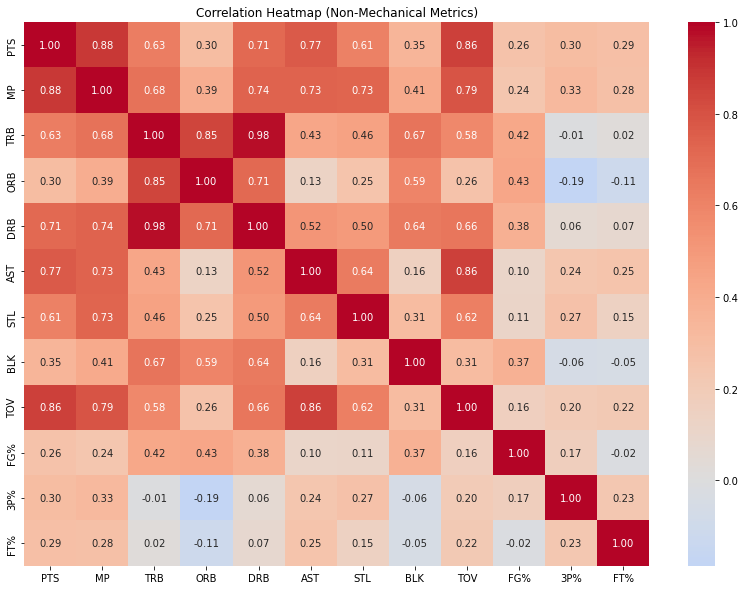

In [37]:
key_vars = [
    "PTS","MP","TRB","ORB","DRB","AST",
    "STL","BLK","TOV","FG%","3P%","FT%",
]

corr_matrix = df_clean[key_vars].corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Non-Mechanical Metrics)")
plt.show()

### Insights:

the heatmap tells that scoring is strongly associated with the minutes played (which gives the players more opportunity to play) and offensive involvement; turnovers and assists. Defensive rebounds is also strongly associated with scoring. In contrast, efficiency metrics like FG%, 3P%, and FT% are weakly associated with scoring, suggesting that scoring is influenced more by opportunity and usage than pure shooting efficiency.

In [38]:
df_clean.sort_values("PTS", ascending=False)[["Player","Pos","MP","PTS"]].head(10)

,Player,Pos,MP,PTS
0,Shai Gilgeous-Alexander,PG,34.2,32.7
1,Giannis Antetokounmpo,PF,34.2,30.4
2,Nikola Jokić,C,36.7,29.6
3,Luka Dončić,PG,35.4,28.2
6,Anthony Edwards,SG,36.3,27.6
7,Jayson Tatum,PF,36.4,26.8
8,Kevin Durant,PF,36.5,26.6
9,Tyrese Maxey,PG,37.7,26.3
10,Cade Cunningham,PG,35.0,26.1
11,Jalen Brunson,PG,35.4,26.0


In [39]:
df_clean["PTS_per_min"] = df_clean["PTS"] / df_clean["MP"]
df_clean.groupby("Pos")["PTS_per_min"].mean()

Pos
C     0.442639
PF    0.423448
PG    0.446673
SF    0.417343
SG    0.422940
Name: PTS_per_min, dtype: float64

In [40]:
df_clean.groupby("Pos")["PF"].mean().sort_values(ascending=False)

Pos
C     1.875309
PF    1.631683
SF    1.538298
PG    1.497872
SG    1.471141
Name: PF, dtype: float64

In [41]:
df_clean["MP"].corr(df_clean["PTS_per_min"])

0.5101024455846257

In [42]:
df_filtered = df_clean[df_clean["MP"] > 25]

top_scorer = (
    df_filtered.groupby("Player")["PTS_per_min"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
top_scorer

,Player,PTS_per_min
0,Shai Gilgeous-Alexander,0.956140
1,Giannis Antetokounmpo,0.888889
2,Zion Williamson,0.860140
3,Nikola Jokić,0.806540
4,Luka Dončić,0.796610
5,Joel Embiid,0.788079
6,LaMelo Ball,0.787500
7,Cam Thomas,0.769231
8,Donovan Mitchell,0.764331
9,Ja Morant,0.763158


In [78]:
fig = px.bar(
    top_scorer,
    x="Player",
    y="PTS_per_min",
    title="Top 25 Players by Points per Minute",
    labels={"PTS_per_min": "Points per Minute"},
    color='PTS_per_min',
    height=500
)

fig.update_layout(xaxis_tickangle=-45)

fig.show()

### Insights:

The top five scorer are Shai Gilgeous-Alexander, Giannis, Jokic, Luka, and Edwards. They have longer playing time ranging from 34 minutes to 37 minutes. This also proves that higher playing time means more opportunity to score. Interms of points per minute by position, PG and C dominates the list. Here, the correlation relationship between minutes played and PTS_per_min is moderate (0.51) which still means better players still get more minutes. Top scorers per minute are almost same as top five scorer who are Shai, Giannis, Zion, Jokic, and Luka.

In [79]:
df_clean["PF_per_min"] = df_clean["PF"] / df_clean["MP"]

In [101]:
df_filtered02 = df_clean[df_clean["MP"] > 25]
high_pf = (
    df_filtered02.groupby(["Player", "Pos"], as_index=False)["PF_per_min"]
    .mean()
    .sort_values("PF_per_min", ascending=False)
    .head(15)
    .reset_index()
)
high_pf

,index,Player,Pos,PF_per_min
0,83,Jaren Jackson Jr.,C,0.117450
1,113,Kyshawn George,SG,0.113208
2,170,Wendell Carter Jr.,C,0.111969
3,53,Draymond Green,PF,0.109589
4,68,Isaiah Hartenstein,C,0.107527
5,73,Jakob Poeltl,C,0.104730
6,114,LaMelo Ball,PG,0.103125
7,94,Jordan Poole,SG,0.102041
8,65,Herbert Jones,SF,0.101852
9,150,Scoot Henderson,PG,0.101124


In [102]:
fig = px.bar(
    high_pf,
    x="Player",
    y="PF_per_min",
    title="Players with Highest Personal Foul",
    labels={"PF_per_min" : "Personal foul per minute"},
    color='Pos',
    height=500
)

fig.update_layout(xaxis_tickangle=-45)

fig.show()
print("Correlation PF vs PTS:", df_clean["PF"].corr(df_clean["PTS"]))

Correlation PF vs PTS: 0.6091987498796585


### Insights:

Personal fouls have moderate positive correlation with scoring (0.60). However, this does not mean fouling causes scoring but it means players who score more tend to commit more personal fouls. It likely involves higher minutes played, greater defensive involvement, and more physical work.

In [67]:
df_clean["AST_per_min"] = df_clean["AST"] / df_clean["MP"]

In [68]:
df_filtered03 = df_clean[df_clean["MP"] > 25]

top_ast = (
    df_filtered03.groupby("Player")["AST_per_min"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
    .round(2)
)
top_ast

,Player,AST_per_min
0,Trae Young,0.32
1,Nikola Jokić,0.28
2,Tyrese Haliburton,0.27
3,Chris Paul,0.26
4,Cade Cunningham,0.26
5,James Harden,0.25
6,Isaiah Collier,0.24
7,Ja Morant,0.24
8,Josh Giddey,0.24
9,LeBron James,0.23


In [49]:
fig = px.bar(
    top_ast,
    x="Player",
    y="AST_per_min",
    title="Players with Highest Assists",
    labels={"AST_per_min" : "Assists per minute"},
    color='AST_per_min',
    height=500
)

fig.update_layout(xaxis_tickangle=-45)

fig.show()
print("Correlation AST vs PTS:", df_clean["AST"].corr(df_clean["PTS"]))

Correlation AST vs PTS: 0.7712053247443271


### Insights:

Assist is strongly associated with scoring (0.77), meaning that offensive usage plays a critical role in overall scoring output. Players with highest assists are Trae Young, Nikola Jokic, and Tyrese Haliburton.


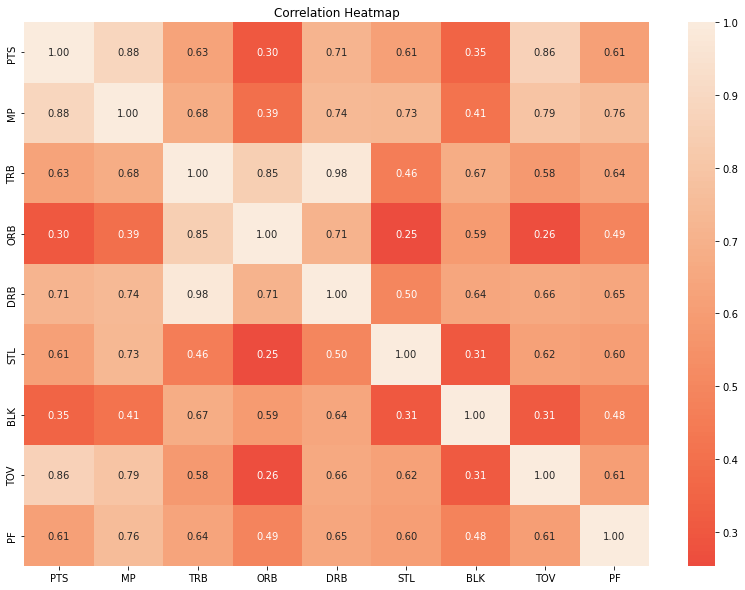

In [50]:
key2_vars = [
    "PTS","MP","TRB","ORB","DRB", "Pos", 
    "STL","BLK","TOV", "PF"
]

corr_matrix2 = df_clean[key2_vars].corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix2, annot=True, fmt=".2f", cmap="rocket", center=0)
plt.title("Correlation Heatmap")
plt.show()

### Insights:

Players who play more and handle the ball more tend to have higher stats in almost everything, points, turnovers, rebounds, and fouls. The heatmap shows that opportunity and role are more important than just shooting efficiency.